In [ ]:
# CELL 1 - RUN THIS FIRST
import tensorflow as tf
import gc
from tensorflow import keras

# Clear and configure GPU
keras.backend.clear_session()
gc.collect()

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print("✓ GPU configured")

✓ GPU configured


In [46]:
# ============================================================================
# FIXED GRAD-CAM LOCALIZATION EVALUATION
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import tensorflow as tf
from tensorflow import keras
import cv2
import os


In [ ]:
# ============================================================================
# CONFIGURATION
# ============================================================================

IMAGE_SIZE = 224
ORIGINAL_SIZE = 1024  # Original image dimensions
MODEL_PATH = './output/emn_pneumo.keras'
CSV_PATH = './dataset_pneumothorax/pneumothorax_xy.csv'
IMAGE_DIR = './dataset_pneumothorax/images'

In [ ]:
# ============================================================================
# LOAD DATA AND MODEL
# ============================================================================

df = pd.read_csv(CSV_PATH)
model = keras.models.load_model(MODEL_PATH)

print(f"Loaded {len(df)} pneumothorax images with bounding boxes")
print(f"Scale factor: {IMAGE_SIZE}/{ORIGINAL_SIZE} = {IMAGE_SIZE/ORIGINAL_SIZE:.4f}")

Loaded 98 pneumothorax images with bounding boxes
Scale factor: 224/1024 = 0.2188


In [49]:
# ============================================================================
# GRAD-CAM FUNCTION - FIXED VERSION
# ============================================================================

def make_gradcam_heatmap(img_array, model, last_conv_layer_name='conv5_block3_out'):
    """Generate Grad-CAM heatmap for ResNet50V2-based model."""
    base_model = model.get_layer('resnet50v2')
    
    # Create model to extract conv features
    conv_model = keras.models.Model(
        inputs=base_model.input,
        outputs=base_model.get_layer(last_conv_layer_name).output
    )
    
    with tf.GradientTape() as tape:
        conv_outputs = conv_model(img_array)
        tape.watch(conv_outputs)
        
        # Manual forward pass through remaining layers
        pooled = tf.reduce_mean(conv_outputs, axis=[1, 2], keepdims=False)
        predictions = model.layers[-1](pooled)  # Dense layer
        
        loss = predictions[0][0]
    
    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    heatmap = conv_outputs[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0)
    
    if tf.math.reduce_max(heatmap) != 0:
        heatmap = heatmap / tf.math.reduce_max(heatmap)
    
    return cv2.resize(heatmap.numpy(), (IMAGE_SIZE, IMAGE_SIZE))

In [50]:
# ============================================================================
# LOAD AND PREPROCESS WITH SCALING
# ============================================================================

def load_and_preprocess_image(image_path):
    """Load image and calculate scale factor."""
    img = tf.io.read_file(image_path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, [IMAGE_SIZE, IMAGE_SIZE])
    
    img_display = img.numpy().astype(np.uint8)
    img = tf.keras.applications.resnet_v2.preprocess_input(img)
    img_array = tf.expand_dims(img, 0)
    
    scale_factor = IMAGE_SIZE / ORIGINAL_SIZE
    
    return img_array, img_display, scale_factor

In [51]:
# ============================================================================
# METRICS FUNCTIONS
# ============================================================================

def compute_iou_from_heatmap(heatmap, bbox, threshold=0.5):
    """Compute IoU between thresholded heatmap and ground truth bbox."""
    binary_map = (heatmap >= threshold).astype(np.uint8)
    
    gt_mask = np.zeros_like(binary_map)
    x, y, w, h = bbox
    x, y, w, h = int(x), int(y), int(w), int(h)
    
    # Ensure bbox is within image bounds
    x = max(0, min(x, IMAGE_SIZE))
    y = max(0, min(y, IMAGE_SIZE))
    w = max(0, min(w, IMAGE_SIZE - x))
    h = max(0, min(h, IMAGE_SIZE - y))
    
    gt_mask[y:y+h, x:x+w] = 1
    
    intersection = np.logical_and(binary_map, gt_mask).sum()
    union = np.logical_or(binary_map, gt_mask).sum()
    
    iou = intersection / union if union > 0 else 0.0
    
    return iou

def pointing_game(heatmap, bbox):
    """Check if max attention is inside bounding box."""
    max_loc = np.unravel_index(np.argmax(heatmap), heatmap.shape)
    max_y, max_x = max_loc
    
    x, y, w, h = bbox
    hit = (x <= max_x < x+w) and (y <= max_y < y+h)
    
    return 1 if hit else 0

In [52]:
# ============================================================================
# EVALUATION ON RANDOM SAMPLE - FIXED
# ============================================================================

# Select random sample
#sample = df.sample(1).iloc[0] #random
# Select specific image by name
specific_image_name = '00014822_039.png'  # Replace with your desired image name
sample = df[df['Image Index'] == specific_image_name].iloc[0]

image_name = sample['Image Index']
x_orig = float(sample['x'])
y_orig = float(sample['y'])
w_orig = float(sample['w'])
h_orig = float(sample['h'])

print(f"\n{'='*80}")
print(f"EVALUATION ON SAMPLE IMAGE")
print(f"{'='*80}")
print(f"Image: {image_name}")
print(f"Original BBox (1024x1024): x={x_orig:.1f}, y={y_orig:.1f}, w={w_orig:.1f}, h={h_orig:.1f}")

# Load image WITH scale factor
image_path = os.path.join(IMAGE_DIR, image_name)
img_array, img_display, scale_factor = load_and_preprocess_image(image_path)

# SCALE BOUNDING BOX TO 224x224
x = x_orig * scale_factor
y = y_orig * scale_factor
w = w_orig * scale_factor
h = h_orig * scale_factor
bbox = [x, y, w, h]

print(f"Scaled BBox (224x224): x={x:.1f}, y={y:.1f}, w={w:.1f}, h={h:.1f}")
print(f"Scale factor: {scale_factor:.4f}")

# Get prediction
prediction = model.predict(img_array, verbose=0)[0][0]
print(f"\nModel Prediction: {prediction:.4f} (Pneumothorax probability)")

# Generate Grad-CAM
heatmap = make_gradcam_heatmap(img_array, model)

# Compute metrics
iou = compute_iou_from_heatmap(heatmap, bbox, threshold=0.5)
pointing_acc = pointing_game(heatmap, bbox)

print(f"\n{'='*80}")
print(f"LOCALIZATION METRICS")
print(f"{'='*80}")
print(f"IoU (Intersection over Union): {iou:.4f}")
print(f"Pointing Game Accuracy: {pointing_acc} ({'HIT ✓' if pointing_acc else 'MISS ✗'})")


EVALUATION ON SAMPLE IMAGE
Image: 00014822_039.png
Original BBox (1024x1024): x=644.6, y=205.1, w=194.6, h=623.5
Scaled BBox (224x224): x=141.0, y=44.9, w=42.6, h=136.4
Scale factor: 0.2188

Model Prediction: 0.8248 (Pneumothorax probability)

LOCALIZATION METRICS
IoU (Intersection over Union): 0.3648
Pointing Game Accuracy: 1 (HIT ✓)


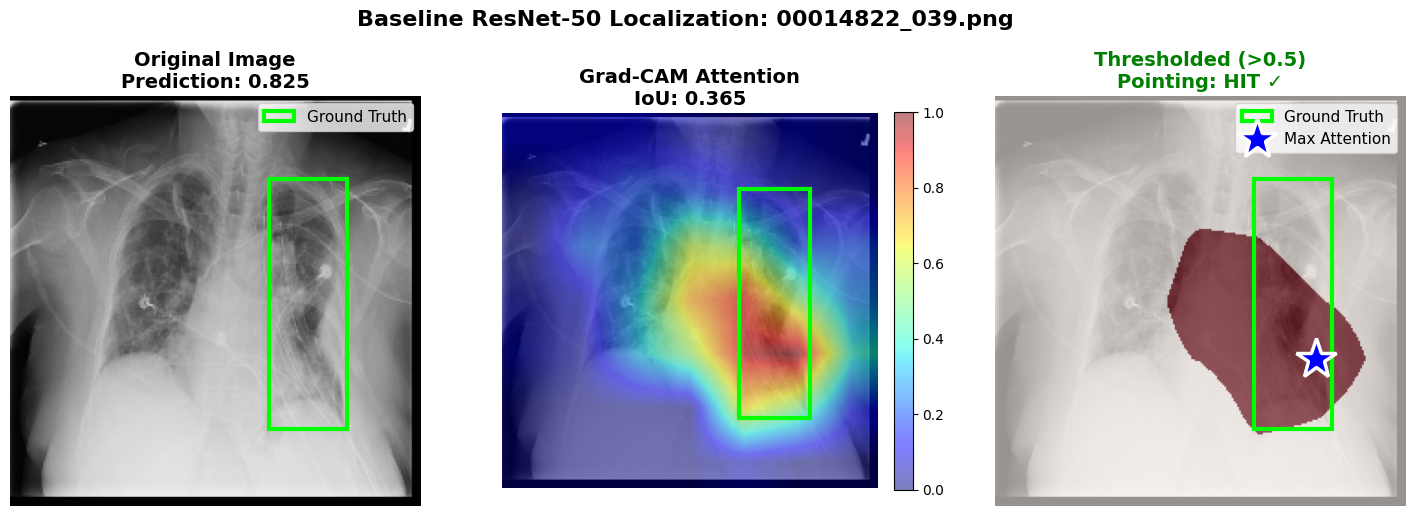

In [53]:
# ============================================================================
# ENHANCED VISUALIZATION
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Original image with bbox
axes[0].imshow(img_display)
rect = patches.Rectangle(
    (x, y), w, h,
    linewidth=3, edgecolor='lime', facecolor='none', label='Ground Truth'
)
axes[0].add_patch(rect)
axes[0].set_title(f'Original Image\nPrediction: {prediction:.3f}', fontsize=14, fontweight='bold')
axes[0].axis('off')
axes[0].legend(fontsize=11, loc='upper right')

# 2. Grad-CAM heatmap overlay
axes[1].imshow(img_display)
heatmap_overlay = axes[1].imshow(heatmap, cmap='jet', alpha=0.5, vmin=0, vmax=1)
rect = patches.Rectangle((x, y), w, h, linewidth=3, edgecolor='lime', facecolor='none')
axes[1].add_patch(rect)
axes[1].set_title(f'Grad-CAM Attention\nIoU: {iou:.3f}', fontsize=14, fontweight='bold')
axes[1].axis('off')
plt.colorbar(heatmap_overlay, ax=axes[1], fraction=0.046, pad=0.04)

# 3. Thresholded attention with max point
binary_map = (heatmap >= 0.5).astype(np.uint8)
axes[2].imshow(img_display)
axes[2].imshow(binary_map, cmap='Reds', alpha=0.6)
rect = patches.Rectangle((x, y), w, h, linewidth=3, edgecolor='lime', 
                         facecolor='none', label='Ground Truth')
axes[2].add_patch(rect)

# Mark max attention point
max_loc = np.unravel_index(np.argmax(heatmap), heatmap.shape)
max_y, max_x = max_loc
axes[2].plot(max_x, max_y, 'b*', markersize=30, markeredgewidth=2.5, 
             markeredgecolor='white', label=f'Max Attention')

color = 'green' if pointing_acc else 'red'
axes[2].set_title(f'Thresholded (>0.5)\nPointing: {"HIT ✓" if pointing_acc else "MISS ✗"}', 
                  fontsize=14, fontweight='bold', color=color)
axes[2].axis('off')
axes[2].legend(fontsize=11, loc='upper right')

plt.suptitle(f'Baseline ResNet-50 Localization: {image_name}', 
             fontsize=16, fontweight='bold')
plt.subplots_adjust()
plt.show()


In [54]:
# ============================================================================
# DEBUG INFO
# ============================================================================

print(f"\n{'='*80}")
print(f"DEBUG INFORMATION")
print(f"{'='*80}")
print(f"BBox center (scaled): ({x + w/2:.1f}, {y + h/2:.1f})")
print(f"Max attention location: ({max_x}, {max_y})")
print(f"Distance from bbox center: {np.sqrt((max_x - (x+w/2))**2 + (max_y - (y+h/2))**2):.1f} pixels")
print(f"Heatmap max value: {heatmap.max():.4f}")
print(f"Heatmap mean value: {heatmap.mean():.4f}")
print(f"Binary map coverage: {binary_map.sum()} pixels ({100*binary_map.sum()/(IMAGE_SIZE*IMAGE_SIZE):.2f}%)")
print(f"Ground truth bbox area: {int(w*h)} pixels ({100*w*h/(IMAGE_SIZE*IMAGE_SIZE):.2f}%)")


DEBUG INFORMATION
BBox center (scaled): (162.3, 113.1)
Max attention location: (175, 143)
Distance from bbox center: 32.5 pixels
Heatmap max value: 0.9917
Heatmap mean value: 0.2187
Binary map coverage: 7629 pixels (15.20%)
Ground truth bbox area: 5804 pixels (11.57%)
